# 1_Cálculo del valor de decisión óptimo para el caso de una regla de decisión MAP en una observación continua


## Consigna

Considere una variable aleatoria

$$
X \in \{-1,+3\}
$$

con probabilidades a priori

$$
P_X(-1)=0.4, \qquad P_X(+3)=0.6.
$$

Dada una observación $y$ de la variable aleatoria

$$
Y=X+N,
$$

donde $N$ es una variable aleatoria gaussiana independiente de $X$, con media $\mu_N=0$ y varianza

$$
\sigma^2=0.4,
$$

se pide:

1. Encontrar el nivel de decisión para un detector MAP.
2. Calcular analíticamente la probabilidad de error $P_e$.


## Datos del problema

Vamos a nombrar:

$$
x_0=-1, \qquad x_1=+3
$$

$$
P_X(x_0)=P_X(-1)=p_0=0.4
$$

$$
P_X(x_1)=P_X(+3)=p_1=0.6
$$

Como $Y=X+N$ y $N\sim\mathcal N(0,\sigma^2)$, entonces:

$$
Y\mid X=x_0 \sim \mathcal N(-1,0.4)
$$

$$
Y\mid X=x_1 \sim \mathcal N(3,0.4).
$$

Las densidades condicionales son:

$$
f_{Y\mid X}(y\mid -1)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y+1)^2}{2\sigma^2}\right]
$$

$$
f_{Y\mid X}(y\mid +3)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y-3)^2}{2\sigma^2}\right].
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt, log

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260508)

x0 = -1.0
x1 = 3.0
p0 = 0.4
p1 = 0.6
sigma2 = 0.4
sigma = np.sqrt(sigma2)

def gaussian_pdf(y, mean, sigma2):
    return (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-((y - mean) ** 2) / (2 * sigma2))

def Q(x):
    return 0.5 * (1 - erf(x / sqrt(2)))


## Visualización de las densidades ponderadas

Para MAP no se comparan solamente las densidades $f_{Y\mid X}(y\mid x_i)$, sino las densidades ponderadas por las probabilidades a priori:

$$
P_X(x_i)f_{Y\mid X}(y\mid x_i).
$$

El punto donde se cruzan esas curvas es el umbral de decisión MAP.


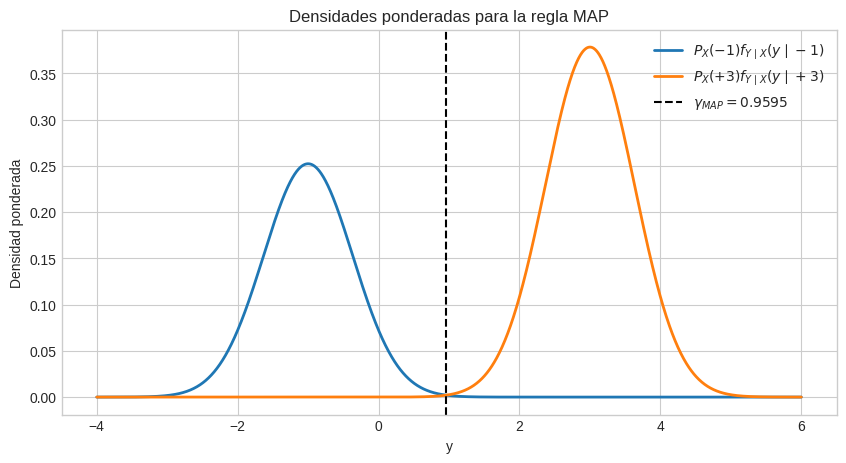

gamma_MAP = 0.959453


In [2]:
gamma_map = (x0 + x1) / 2 + (sigma2 / (x1 - x0)) * np.log(p0 / p1)

y_values = np.linspace(-4, 6, 2000)
weighted_h0 = p0 * gaussian_pdf(y_values, x0, sigma2)
weighted_h1 = p1 * gaussian_pdf(y_values, x1, sigma2)

plt.figure(figsize=(10, 5))
plt.plot(y_values, weighted_h0, label=r"$P_X(-1)f_{Y\mid X}(y\mid -1)$", linewidth=2)
plt.plot(y_values, weighted_h1, label=r"$P_X(+3)f_{Y\mid X}(y\mid +3)$", linewidth=2)
plt.axvline(gamma_map, color="black", linestyle="--", label=fr"$\gamma_{{MAP}}={gamma_map:.4f}$")
plt.xlabel("y")
plt.ylabel("Densidad ponderada")
plt.title("Densidades ponderadas para la regla MAP")
plt.legend()
plt.show()

print(f"gamma_MAP = {gamma_map:.6f}")


## 1. Nivel de decisión MAP

La regla MAP decide el valor de $X$ que maximiza la probabilidad a posteriori:

$$
\hat X_{MAP}(y)=\arg\max_{x_i\in\{-1,+3\}} P_{X\mid Y}(x_i\mid y).
$$

Usando Bayes, como $f_Y(y)$ es común para ambas hipótesis, alcanza con comparar:

$$
P_X(+3)f_{Y\mid X}(y\mid +3)
\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
P_X(-1)f_{Y\mid X}(y\mid -1).
$$

Reemplazando los valores:

$$
0.6\cdot \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y-3)^2}{2\sigma^2}\right]
\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
0.4\cdot \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y+1)^2}{2\sigma^2}\right].
$$

Cancelamos el factor común $1/\sqrt{2\pi\sigma^2}$:

$$
0.6\exp\left[-\frac{(y-3)^2}{2\sigma^2}\right]
\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
0.4\exp\left[-\frac{(y+1)^2}{2\sigma^2}\right].
$$

Aplicamos logaritmo natural:

$$
\ln(0.6)-\frac{(y-3)^2}{2\sigma^2}
\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
\ln(0.4)-\frac{(y+1)^2}{2\sigma^2}.
$$

Pasamos términos:

$$
\frac{(y+1)^2-(y-3)^2}{2\sigma^2}
\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
\ln\left(\frac{0.4}{0.6}\right).
$$

Calculamos la diferencia de cuadrados:

$$
(y+1)^2-(y-3)^2=(y^2+2y+1)-(y^2-6y+9)=8y-8.
$$

Como $2\sigma^2=2\cdot0.4=0.8$:

$$
\frac{8y-8}{0.8}\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}\ln\left(\frac{0.4}{0.6}\right).
$$

$$
10(y-1)\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}\ln\left(\frac{2}{3}\right).
$$

Despejamos $y$:

$$
y\overset{\hat X=+3}{\underset{\hat X=-1}{\gtreqless}}
1+\frac{1}{10}\ln\left(\frac{2}{3}\right).
$$

Por lo tanto:

$$
\boxed{\gamma_{MAP}=1+0.1\ln\left(\frac{2}{3}\right)}
$$

$$
\boxed{\gamma_{MAP}\approx0.95945}
$$

La regla de decisión queda:

$$
\boxed{\hat X=+3 \quad \text{si} \quad y\ge\gamma_{MAP}}
$$

$$
\boxed{\hat X=-1 \quad \text{si} \quad y<\gamma_{MAP}}
$$

El umbral queda apenas a la izquierda del punto medio $1$, porque $+3$ tiene mayor probabilidad a priori que $-1$.


## 2. Probabilidad de error analítica

Hay dos formas de equivocarse:

- se transmitió $X=-1$ y se decide $\hat X=+3$;
- se transmitió $X=+3$ y se decide $\hat X=-1$.

Entonces:

$$
P_e=P_X(-1)P(Y\ge\gamma_{MAP}\mid X=-1)+P_X(+3)P(Y<\gamma_{MAP}\mid X=+3).
$$

Bajo $X=-1$:

$$
Y\mid X=-1\sim\mathcal N(-1,0.4).
$$

Por lo tanto:

$$
P(Y\ge\gamma_{MAP}\mid X=-1)=Q\left(\frac{\gamma_{MAP}-(-1)}{\sqrt{0.4}}\right)
=Q\left(\frac{\gamma_{MAP}+1}{\sqrt{0.4}}\right).
$$

Bajo $X=+3$:

$$
Y\mid X=+3\sim\mathcal N(3,0.4).
$$

Por lo tanto:

$$
P(Y<\gamma_{MAP}\mid X=+3)=Q\left(\frac{3-\gamma_{MAP}}{\sqrt{0.4}}\right).
$$

Finalmente:

$$
\boxed{P_e=0.4\,Q\left(\frac{\gamma_{MAP}+1}{\sqrt{0.4}}\right)+0.6\,Q\left(\frac{3-\gamma_{MAP}}{\sqrt{0.4}}\right)}
$$


In [3]:
arg_h0 = (gamma_map - x0) / sigma
arg_h1 = (x1 - gamma_map) / sigma
pe_exact = p0 * Q(arg_h0) + p1 * Q(arg_h1)

print(f"gamma_MAP = {gamma_map:.8f}")
print(f"Argumento Q para error si X=-1: {(gamma_map + 1) / sigma:.8f}")
print(f"Argumento Q para error si X=+3: {(3 - gamma_map) / sigma:.8f}")
print(f"Pe exacta = {pe_exact:.10f}")


gamma_MAP = 0.95945349
Argumento Q para error si X=-1: 3.09816800
Argumento Q para error si X=+3: 3.22638732
Pe exacta = 0.0007655328


## Verificación por Monte Carlo

No reemplaza el cálculo analítico, pero sirve para comprobar que el umbral y la probabilidad de error tienen sentido numérico.


In [4]:
n_samples = 500000
x = np.where(rng.random(n_samples) < p0, x0, x1)
noise = rng.normal(loc=0.0, scale=sigma, size=n_samples)
y = x + noise
x_hat = np.where(y >= gamma_map, x1, x0)
pe_mc = np.mean(x_hat != x)

print(f"Pe exacta:      {pe_exact:.10f}")
print(f"Pe Monte Carlo: {pe_mc:.10f}")
print(f"Error absoluto: {abs(pe_exact - pe_mc):.10f}")


Pe exacta:      0.0007655328
Pe Monte Carlo: 0.0007700000
Error absoluto: 0.0000044672


## Respuesta final

El nivel de decisión MAP es:

$$
\boxed{\gamma_{MAP}=1+0.1\ln\left(\frac{2}{3}\right)\approx0.95945}
$$

La regla de decisión es:

$$
\boxed{\hat X=+3 \quad \text{si} \quad y\ge0.95945}
$$

$$
\boxed{\hat X=-1 \quad \text{si} \quad y<0.95945}
$$

La probabilidad de error analítica es:

$$
\boxed{P_e=0.4\,Q\left(\frac{\gamma_{MAP}+1}{\sqrt{0.4}}\right)+0.6\,Q\left(\frac{3-\gamma_{MAP}}{\sqrt{0.4}}\right)}
$$

Numéricamente:

$$
\boxed{P_e\approx 7.67\times 10^{-4}}
$$
